In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier


In [8]:
# 2️⃣ CHARGER LE DATASET
# ================================
df = pd.read_csv(r"C:\Users\Admin\Desktop\projet_win\house-prices.csv")
print(df.head())


   Home   Price  SqFt  Bedrooms  Bathrooms  Offers Brick Neighborhood
0     1  114300  1790         2          2       2    No         East
1     2  114200  2030         4          2       3    No         East
2     3  114800  1740         3          2       1    No         East
3     4   94700  1980         3          2       3    No         East
4     5  119800  2130         3          3       3    No         East


In [10]:
# 3️⃣ PRÉTRAITEMENT
# ================================
df["Brick"] = df["Brick"].map({"Yes": 1, "No": 0})

# Création de la cible binaire
df["Price_Class"] = (df["Price"] > df["Price"].median()).astype(int)

X = df[["SqFt", "Bedrooms", "Bathrooms", "Offers", "Brick"]]
y = df["Price_Class"]


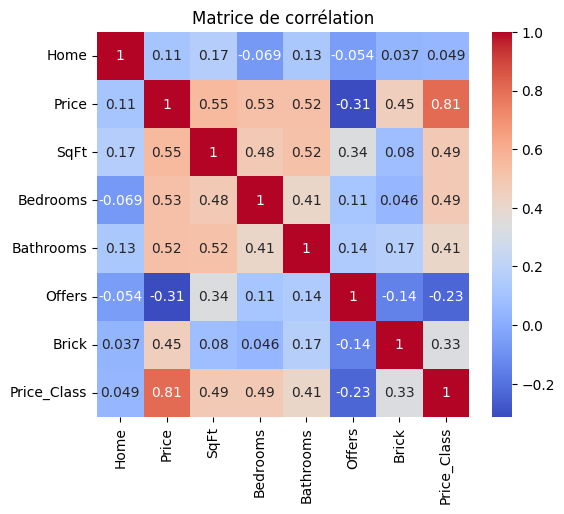

In [12]:
# 4️⃣ MATRICE DE CORRÉLATION
# ================================
plt.figure(figsize=(6,5))
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True, cmap="coolwarm")
plt.title("Matrice de corrélation")
plt.show()

In [14]:

# 5️⃣ SPLIT
# ================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [16]:
# 6️⃣ MODÈLES
# ================================
models = {
    "Régression Logistique": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression())
    ]),
    "KNN": Pipeline([
        ("scaler", StandardScaler()),
        ("model", KNeighborsClassifier(n_neighbors=7))
    ]),
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42
    )
}

results = {}


📌 Modèle : Régression Logistique
Accuracy : 0.8076923076923077
Precision: 0.7857142857142857
Recall   : 0.8461538461538461
F1-score : 0.8148148148148148

Rapport de classification :
              precision    recall  f1-score   support

           0       0.83      0.77      0.80        13
           1       0.79      0.85      0.81        13

    accuracy                           0.81        26
   macro avg       0.81      0.81      0.81        26
weighted avg       0.81      0.81      0.81        26



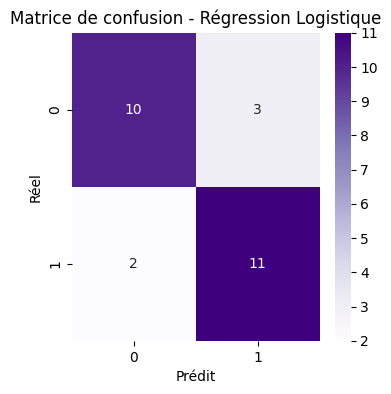


📌 Modèle : KNN
Accuracy : 0.6923076923076923
Precision: 0.6666666666666666
Recall   : 0.7692307692307693
F1-score : 0.7142857142857143

Rapport de classification :
              precision    recall  f1-score   support

           0       0.73      0.62      0.67        13
           1       0.67      0.77      0.71        13

    accuracy                           0.69        26
   macro avg       0.70      0.69      0.69        26
weighted avg       0.70      0.69      0.69        26



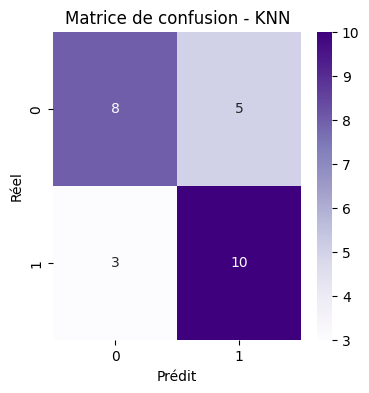


📌 Modèle : Random Forest
Accuracy : 0.7307692307692307
Precision: 0.6875
Recall   : 0.8461538461538461
F1-score : 0.7586206896551724

Rapport de classification :
              precision    recall  f1-score   support

           0       0.80      0.62      0.70        13
           1       0.69      0.85      0.76        13

    accuracy                           0.73        26
   macro avg       0.74      0.73      0.73        26
weighted avg       0.74      0.73      0.73        26



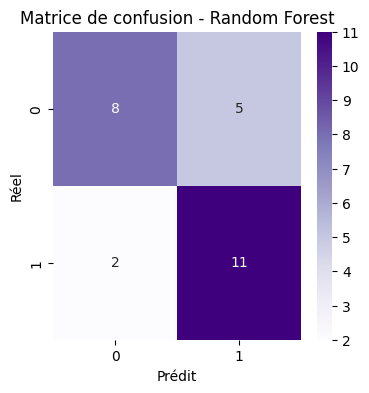

In [18]:
# 7️⃣ ENTRAÎNEMENT & ÉVALUATION
# ================================
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    results[name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred)
    }

    print(f"\n📌 Modèle : {name}")
    print("Accuracy :", results[name]["Accuracy"])
    print("Precision:", results[name]["Precision"])
    print("Recall   :", results[name]["Recall"])
    print("F1-score :", results[name]["F1-score"])
    print("\nRapport de classification :")
    print(classification_report(y_test, y_pred))

    # Matrice de confusion
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(4,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Purples")
    plt.title(f"Matrice de confusion - {name}")
    plt.xlabel("Prédit")
    plt.ylabel("Réel")
    plt.show()


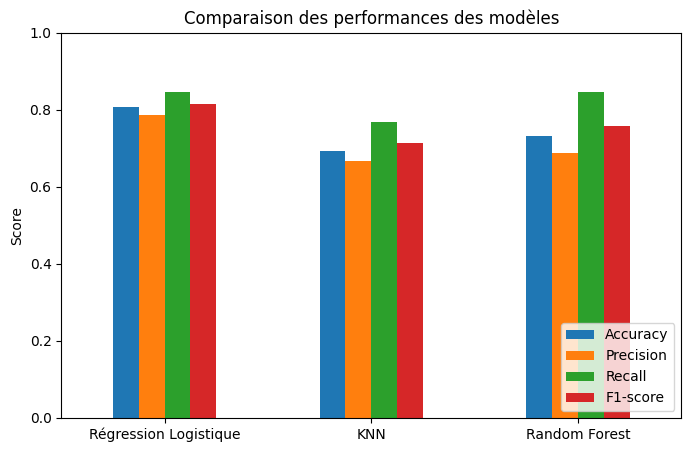

In [20]:

# 8️⃣ GRAPHE DE PERFORMANCE
# ================================
results_df = pd.DataFrame(results).T

results_df.plot(kind="bar", figsize=(8,5))
plt.title("Comparaison des performances des modèles")
plt.ylabel("Score")
plt.ylim(0,1)
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.show()
